### DataBase로부터 Service를 이용

현재까지 지원되는 기능으로는

- `IndustryService`
- `FreightService`
- `PriceService`
- `MacroService`

가 있음.

In [90]:
import pandas as pd
import numpy as np
from sympy import false

from src.service.industry import IndustryService
from src.service.freight import FreightService
from src.service.market import PriceService
from src.service.macro import MacroService
from src.service.behavior import BehaviorService

behavior = BehaviorService(db_path='../database/alternative_data.duckdb')
freights = FreightService(db_path='../database/alternative_data.duckdb')
industry = IndustryService(db_path='../database/alternative_data.duckdb')
macro = MacroService(db_path = '../database/alternative_data.duckdb')
market = PriceService(db_path = '../database/alternative_data.duckdb')

In [5]:
freights.get_series(
    symbols = freights.available_symbols(),
    index_set = 'release_date',
    full_data = False
)

symbol,BAI00,BAI20,BAI30,BAI40,BAI50,BAI60,BAI80,BCI,BCTI,BDI,...,USRT,WCI,WCILASH,WCINYRD,WCIRDNY,WCIRDSH,WCISHGN,WCISHLA,WCISHNY,WCISHRD
release_date,,,,,,,,,,,,,,,,,,,,,
1990-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1602.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1609.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1619.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1637.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1644.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4285.0,1352.0,2743.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-27,2393.0,1020.0,4017.0,1265.0,1113.0,309.0,5463.0,4200.0,1379.0,2696.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140.0,1431.0,2664.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='release_date'>

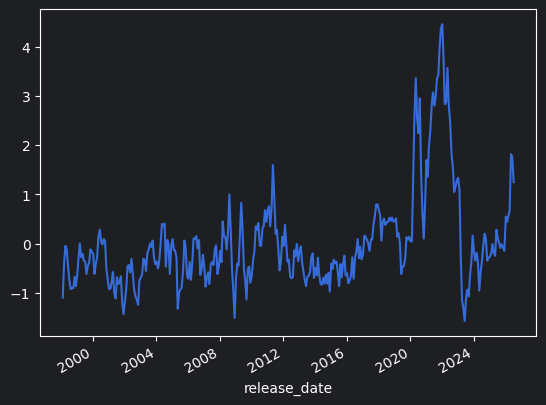

In [6]:
freights.get_series(
    symbols = 'GSCPI',
    index_set = 'release_date',
    full_data = False
).plot()

<Axes: xlabel='base_date'>

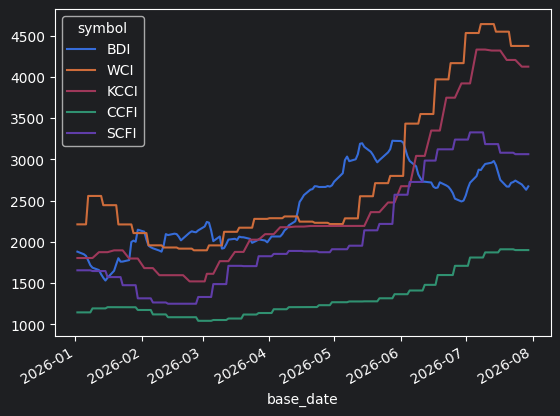

In [7]:
freights.get_series(
    symbols = [
        'BDI','WCI','KCCI','CCFI','SCFI'
    ]
).ffill().loc['2026':].plot()

In [8]:
industry.get_series(
    symbols = ['DXDDR5M16G','DXDDR4M16G','DXDDR4M8G'],
    full_data = True
).xs('average', axis = 1, level = 1)

symbol,DXDDR4M16G,DXDDR4M8G,DXDDR5M16G
base_date_full,,,
2022-01-28 19:10:00+09:00,NaN,3.890,NaN
2022-02-07 19:10:00+09:00,NaN,3.890,NaN
2022-02-08 19:10:00+09:00,NaN,3.890,NaN
2022-02-09 19:10:00+09:00,NaN,3.890,NaN
2022-02-10 19:10:00+09:00,NaN,3.870,NaN
...,...,...,...
2026-07-30 12:00:00+09:00,84.976,42.130,50.933
2026-07-30 15:40:00+09:00,84.976,42.130,50.933
2026-07-30 19:10:00+09:00,84.976,42.130,50.967


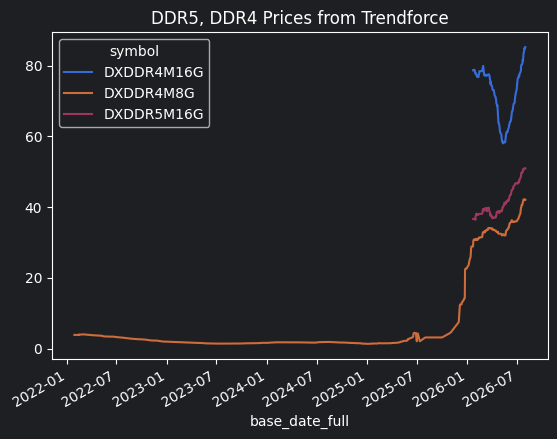

In [9]:
import matplotlib.pyplot as plt

industry.get_series(
    symbols = ['DXDDR5M16G','DXDDR4M16G','DXDDR4M8G'],
    full_data = True
).xs('average', axis = 1, level = 1).plot()
plt.title('DDR5, DDR4 Prices from Trendforce')
plt.show()

<Axes: xlabel='release_date_full'>

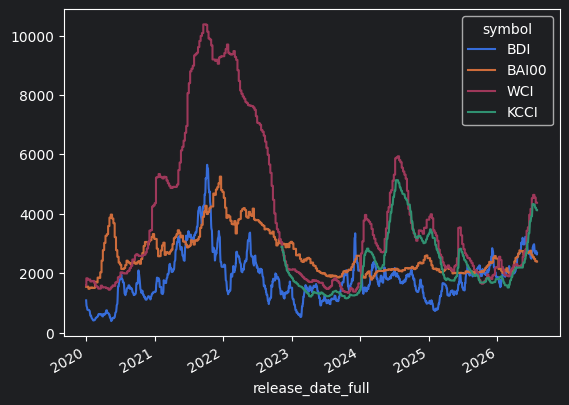

In [10]:
freights.get_series(symbols = ['BDI','BAI00','WCI','KCCI'], index_set = 'release_date', full_data = True).ffill().loc['2020':].plot()

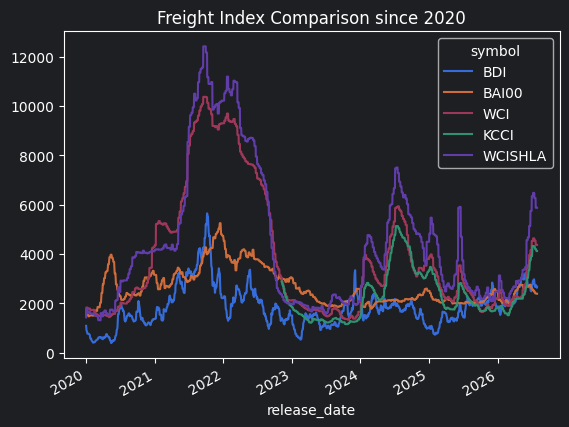

In [11]:
import matplotlib.pyplot as plt

freights.get_series(symbols = ['BDI','BAI00','WCI','KCCI','WCISHLA'], index_set = 'release_date').ffill().loc['2020':].plot()
plt.title('Freight Index Comparison since 2020')
plt.show()

In [12]:
industry = IndustryService(
    db_path = '../database/alternative_data.duckdb'
)

In [13]:
sam_ind = industry.get_series(
    symbols = ['DXI','CFMDRAM'],
    full_data = True
)

<Axes: xlabel='base_date_full'>

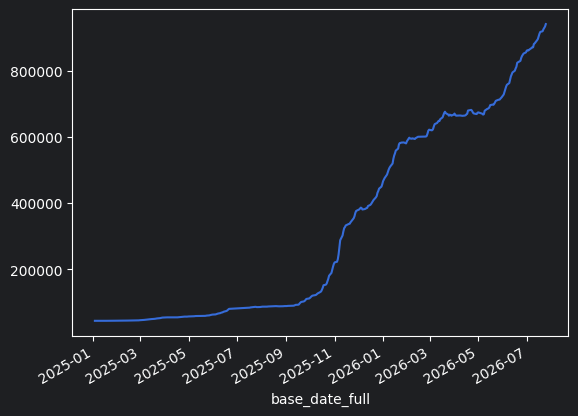

In [14]:
sam_ind['DXI'].dropna().loc['2025':].plot()

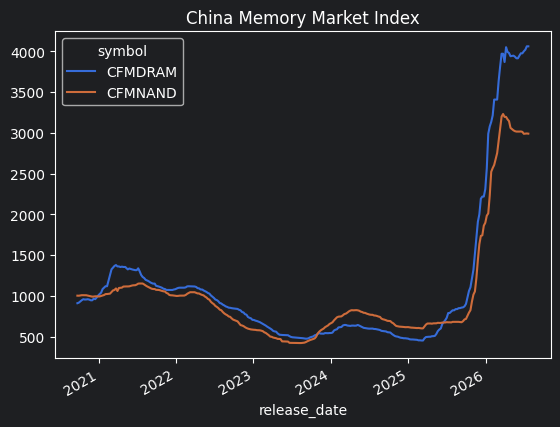

In [15]:
industry.get_series(
    symbols = ['CFMDRAM','CFMNAND'],
    index_set = 'release_date'
).plot()
plt.title('China Memory Market Index')
plt.show()

In [16]:
from src.service.macro import MacroService

macro = MacroService(db_path='../database/alternative_data.duckdb')

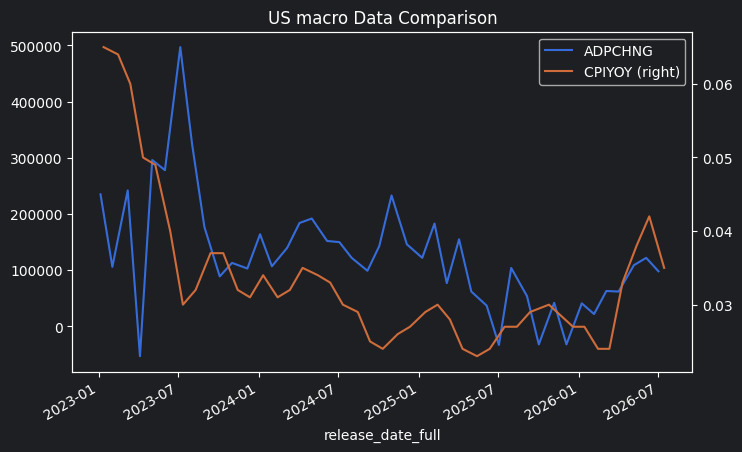

In [17]:
ax = macro.get_series(
    symbols=['ADPCHNG'],
    index_set='release_date',
    full_data=True,
    tz='utc-4',
).loc['2023':]['ADPCHNG'].plot(
    figsize=(8, 5),
    label='ADPCHNG'
)

ax2 = macro.get_series(
    symbols=['CPIYOY'],
    index_set='release_date',
    full_data=True,
    tz='utc-4',
).loc['2023':]['CPIYOY'].plot(
    ax=ax,
    secondary_y=True,
    label='CPIYOY'
)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='best'
)

plt.title(
    'US macro Data Comparison'
)
plt.show()

<Axes: >

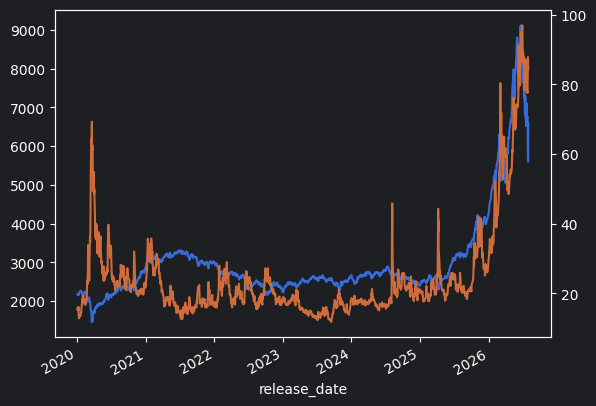

In [18]:
market.get_series(
    symbols = ['KOSPI','VKOSPI'],
    index_set = 'release_date',
    value_column = 'close'
)['KOSPI'].loc['2020':].plot()
market.get_series(
    symbols = ['KOSPI','VKOSPI'],
    index_set = 'release_date',
    value_column = 'close'
)['VKOSPI'].loc['2020':].plot(secondary_y = True)

In [28]:
selected_market_data = market.get_series(
    symbols = ['KOSPI','VKOSPI','KRX300'],
    index_set = 'release_date',
    multi_level_index = False
)#.loc['2020':]

In [29]:
selected_market_data['close']['VKOSPI'].dropna()

release_date
2013-02-04    15.76
2013-02-05    15.79
2013-02-06    15.11
2013-02-07    14.59
2013-02-08    14.25
              ...  
2026-07-10    78.15
2026-07-13    83.33
2026-07-14    83.97
2026-07-15    85.79
2026-07-16    87.14
Name: VKOSPI, Length: 3300, dtype: float64

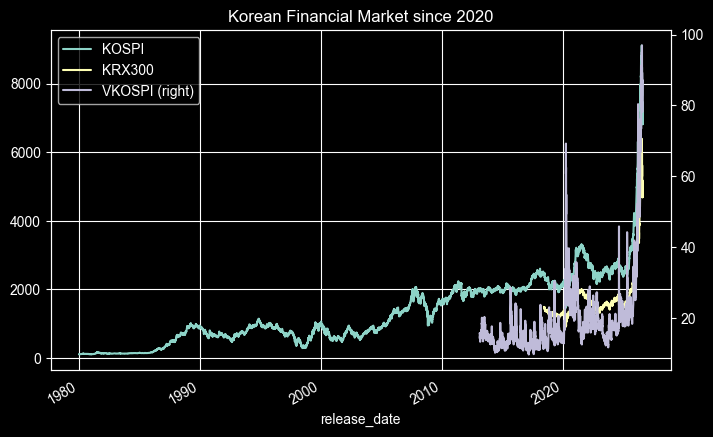

In [30]:
ax = selected_market_data['close']['KOSPI'].plot(
    figsize=(8, 5),
    label='KOSPI'
)

ax2 = selected_market_data['close']['KRX300'].plot(
    ax=ax,
    label='KRX300'
)

ax3 = selected_market_data['close']['VKOSPI'].plot(
    ax = ax,
    secondary_y = True,
    label = 'VKOSPI'
)

lines1, labels1 = ax.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

ax.legend(
    lines1 + lines3,
    labels1 + labels3,
    loc='upper left'
)

plt.title(
    'Korean Financial Market since 2020'
)
plt.show()

In [24]:
selected_market_data = market.get_series(
    symbols = ['NI225','NKVI','VVIX'],
    index_set = 'release_date',
    multi_level_index = False
).loc['2020':]

In [25]:
selected_market_data

field                close                        high                \
symbol               NI225   NKVI   VVIX         NI225   NKVI   VVIX   
release_date                                                           
2020-01-02             NaN    NaN  89.67           NaN    NaN  93.65   
2020-01-03             NaN    NaN  93.79           NaN    NaN  99.92   
2020-01-06    23204.859375  16.87  92.66  23365.359375  16.87  96.41   
2020-01-07    23575.720703  15.11  91.07  23577.439453  15.88  93.44   
2020-01-08    23204.759766  17.25  90.21  23303.210938  19.19  91.57   
...                    ...    ...    ...           ...    ...    ...   
2026-07-01    70474.960938  33.78  89.04  71962.343750  39.52  89.87   
2026-07-02    68733.148438  24.74  88.80  70081.390625  40.42  91.37   
2026-07-03    69744.070312  34.11    NaN  69788.031250  39.51    NaN   
2026-07-06    69737.687500  37.36  87.09  70384.593750  38.32  91.71   
2026-07-07             NaN    NaN  89.49  69957.507812    NaN  90.45   

field                  low                        open                \
symbol               NI225   NKVI   VVIX         NI225   NKVI   VVIX   
release_date                                                           
2020-01-02             NaN    NaN  88.93           NaN    NaN  92.66   
2020-01-03             NaN    NaN  90.68           NaN    NaN  99.92   
2020-01-06    23148.529297  15.74  92.15  23319.759766  16.30  96.37   
2020-01-07    23299.919922  15.00  89.66  23320.119141  15.88  92.80   
2020-01-08    22951.179688  16.38  86.71  23217.490234  16.38  90.33   
...                    ...    ...    ...           ...    ...    ...   
2026-07-01    70126.140625  33.78  87.36  70774.281250  37.78  88.43   
2026-07-02    68676.257812  24.74  86.32  70039.890625  38.82  88.03   
2026-07-03    67609.492188  34.10    NaN  68676.062500  39.20    NaN   
2026-07-06    68904.406250  36.86  87.09  69973.343750  36.97  91.55   
2026-07-07    68003.921875    NaN  87.05  69460.078125    NaN  87.41   

field              volume            
symbol              NI225 NKVI VVIX  
release_date                         
2020-01-02            NaN  NaN  0.0  
2020-01-03            NaN  NaN  0.0  
2020-01-06     72800000.0  0.0  0.0  
2020-01-07     64300000.0  0.0  0.0  
2020-01-08     79400000.0  0.0  0.0  
...                   ...  ...  ...  
2026-07-01    163400000.0  0.0  0.0  
2026-07-02    169900000.0  0.0  0.0  
2026-07-03    159300000.0  0.0  NaN  
2026-07-06    135400000.0  0.0  0.0  
2026-07-07            0.0  NaN  0.0  

[1693 rows x 15 columns]

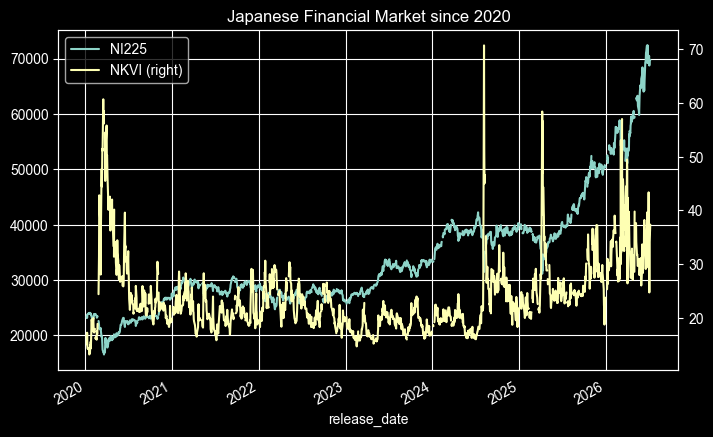

In [26]:
ax = selected_market_data['close']['NI225'].plot(
    figsize=(8, 5),
    label='NI225'
)

ax3 = selected_market_data['close']['NKVI'].plot(
    ax = ax,
    secondary_y = True,
    label = 'NKVI'
)

lines1, labels1 = ax.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

ax.legend(
    lines1 + lines3,
    labels1 + labels3,
    loc='upper left'
)

plt.title(
    'Japanese Financial Market since 2020'
)
plt.show()

<Axes: >

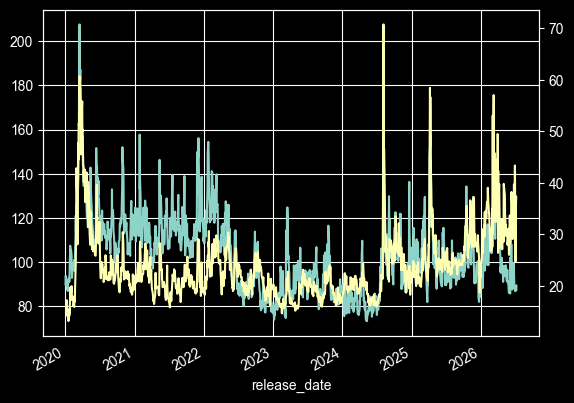

In [27]:
selected_market_data['close']['VVIX'].dropna().plot()
selected_market_data['close']['NKVI'].dropna().plot(secondary_y = True)

In [28]:
market.get_series(
    symbols = ['USDKRW','JPYKRW'],
    full_data = False
)

symbol     JPYKRW                               USDKRW                    \
field       close   high    low   open volume    close     high      low   
base_date                                                                  
1981-04-13    NaN    NaN    NaN    NaN    NaN   675.40   675.40   675.40   
1981-04-14    NaN    NaN    NaN    NaN    NaN   676.70   676.70   676.70   
1981-04-15    NaN    NaN    NaN    NaN    NaN   676.70   676.70   676.70   
1981-04-16    NaN    NaN    NaN    NaN    NaN   676.70   676.70   676.70   
1981-04-17    NaN    NaN    NaN    NaN    NaN   676.75   676.75   676.75   
...           ...    ...    ...    ...    ...      ...      ...      ...   
2026-07-01  9.522  9.564  9.495  9.495    0.0  1553.61  1558.98  1545.90   
2026-07-02  9.529  9.593  9.529  9.545    0.0  1538.00  1557.90  1537.28   
2026-07-03  9.465  9.570  9.465  9.530    0.0  1530.15  1548.28  1526.28   
2026-07-06  9.468  9.497  9.449  9.465    0.0  1530.45  1537.28  1527.38   
2026-07-07  9.334  9.427  9.334  9.427    0.0  1513.83  1531.78  1511.03   

symbol                      
field          open volume  
base_date                   
1981-04-13   675.40    0.0  
1981-04-14   676.70    0.0  
1981-04-15   676.70    0.0  
1981-04-16   676.70    0.0  
1981-04-17   676.75    0.0  
...             ...    ...  
2026-07-01  1546.61    0.0  
2026-07-02  1553.62    0.0  
2026-07-03  1537.99    0.0  
2026-07-06  1529.16    0.0  
2026-07-07  1531.17    0.0  

[11544 rows x 10 columns]

### TEST

In [47]:
cpi = macro.get_series(
    symbols=['CPIYOY'],
    index_set='release_date',
    full_data=False,
    tz='utc-4',
)

In [25]:
selected_market_data = market.get_series(
    symbols = 'SP500',
    index_set = 'release_date',
    multi_level_index = False
)

In [40]:
import numpy as np
import pandas as pd
from typing import Sequence


def _longest_match_length(
    sequence: Sequence[int],
    position: int,
) -> int:
    """
    현재 position에서 시작하는 부분 문자열이 과거 시퀀스에서
    일치하는 최대 길이를 계산합니다.

    Kontoyiannis 추정량에 사용되는 L_i는
    '과거에 등장하지 않은 최소 부분 문자열 길이'이므로
    최대 일치 길이에 1을 더해 반환합니다.
    """
    n = len(sequence)

    if position == 0:
        return 1

    max_match = 0

    # 현재 위치 이전의 모든 시작점과 비교
    for past_position in range(position):
        match_length = 0

        while (
            position + match_length < n
            and past_position + match_length < position
            and sequence[past_position + match_length]
            == sequence[position + match_length]
        ):
            match_length += 1

        max_match = max(max_match, match_length)

    return max_match + 1


def kontoyiannis_entropy(sequence: Sequence[int]) -> float:
    """
    Kontoyiannis entropy-rate estimator.

    Parameters
    ----------
    sequence : Sequence[int]
        0과 1로 구성된 이산 시계열.

    Returns
    -------
    float
        bit 단위의 entropy-rate 추정치.
        값이 낮을수록 반복적이고 예측 가능한 구조가 강합니다.
    """
    sequence = np.asarray(sequence, dtype=int)

    if len(sequence) < 2:
        return np.nan

    if not np.isin(sequence, [0, 1]).all():
        raise ValueError("sequence는 0과 1로만 구성되어야 합니다.")

    estimates = []

    # i=1부터 계산: 첫 번째 관측치에는 비교할 과거가 없음
    for i in range(1, len(sequence)):
        match_length = _longest_match_length(sequence, i)

        estimates.append(
            np.log2(i + 1) / match_length
        )

    return float(np.mean(estimates))


def calculate_rolling_kontoyiannis_entropy(
    price: pd.Series,
    window: int = 20,
) -> pd.DataFrame:
    """
    가격으로부터 수익률, 방향 라벨 및 rolling Kontoyiannis entropy를 계산합니다.

    Parameters
    ----------
    price : pd.Series
        가격 시계열.
    window : int, default 20
        엔트로피 계산 구간.

    Returns
    -------
    pd.DataFrame
        price, return, direction, kontoyiannis_entropy 컬럼.
    """
    if window < 2:
        raise ValueError("window는 2 이상이어야 합니다.")

    price = pd.to_numeric(price, errors="coerce")

    result = pd.DataFrame(index=price.index)
    result["price"] = price
    result["return"] = price.pct_change()

    # 첫 수익률은 NaN이므로 방향도 NaN으로 유지
    result["direction"] = np.where(
        result["return"].isna(),
        np.nan,
        (result["return"] > 0).astype(int),
    )

    entropy_column = f"kontoyiannis_entropy_{window}"

    result[entropy_column] = (
        result["direction"]
        .rolling(window=window, min_periods=window)
        .apply(kontoyiannis_entropy, raw=True)
    )

    return result

In [77]:
df = calculate_rolling_kontoyiannis_entropy(selected_market_data['close'] * selected_market_data['volume'], window = 60)

In [78]:
def extract_entropy_matrix(
    df: pd.DataFrame,
    date_list,
    entropy_col: str = "kontoyiannis_entropy_60",
    window: int = 60,
) -> pd.DataFrame:
    """
    각 기준일 이전부터 기준일까지의 엔트로피 값을 추출하여
    행은 1~window, 열은 각 기준일인 DataFrame을 생성합니다.

    Parameters
    ----------
    df : pd.DataFrame
        DatetimeIndex를 가진 원본 DataFrame.
    date_list : list-like
        추출 기준일 리스트.
    entropy_col : str
        엔트로피 컬럼명.
    window : int
        각 날짜별 추출할 관측치 수.

    Returns
    -------
    pd.DataFrame
        index: 1 ~ window
        columns: 각 기준일
    """
    if entropy_col not in df.columns:
        raise KeyError(f"'{entropy_col}' 컬럼이 존재하지 않습니다.")

    data = df.copy()
    data.index = pd.to_datetime(data.index)
    data = data.sort_index()

    result = {}

    for target_date in pd.to_datetime(date_list):
        # 기준일과 정확히 일치하거나, 기준일 이전의 가장 최근 데이터 위치
        position = data.index.searchsorted(target_date, side="right") - 1

        if position < 0:
            result[target_date] = [pd.NA] * window
            continue

        start_position = position - window + 1

        if start_position < 0:
            # 데이터가 60개보다 적으면 앞부분을 NA로 채움
            values = data.iloc[: position + 1][entropy_col].tolist()
            values = [pd.NA] * (window - len(values)) + values
        else:
            values = (
                data.iloc[start_position : position + 1][entropy_col]
                .tolist()
            )

        result[target_date] = values

    output = pd.DataFrame(
        result,
        index=range(1, window + 1),
    )

    output.index.name = "sequence"

    return output

In [79]:
date_list = list(cpi.index)

In [80]:
entropy_matrix = extract_entropy_matrix(
    df=df,
    date_list=date_list,
    entropy_col="kontoyiannis_entropy_60",
    window=60,
)

<Axes: xlabel='sequence'>

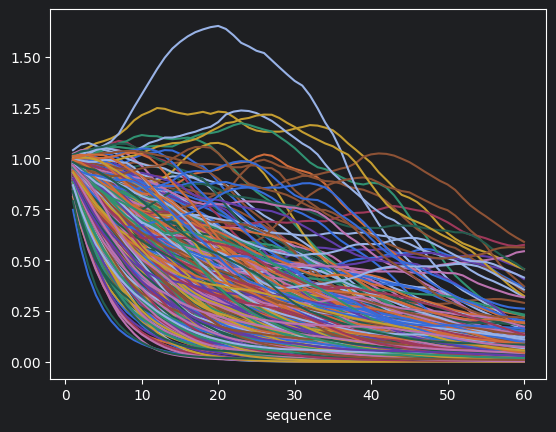

In [84]:
(entropy_matrix).cumprod().plot(legend = False)

In [85]:
cpi_up = cpi[cpi.diff() > 0].dropna().loc['2000':]
cpi_down = cpi[cpi.diff() < 0].dropna().loc['2000':]

In [86]:
entropy_matrix_down = extract_entropy_matrix(
    df=df,
    date_list=list(cpi_down.index),
    entropy_col="kontoyiannis_entropy_60",
    window=60,
)

entropy_matrix_up = extract_entropy_matrix(
    df=df,
    date_list=list(cpi_up.index),
    entropy_col="kontoyiannis_entropy_60",
    window=60,
)

<Axes: xlabel='sequence'>

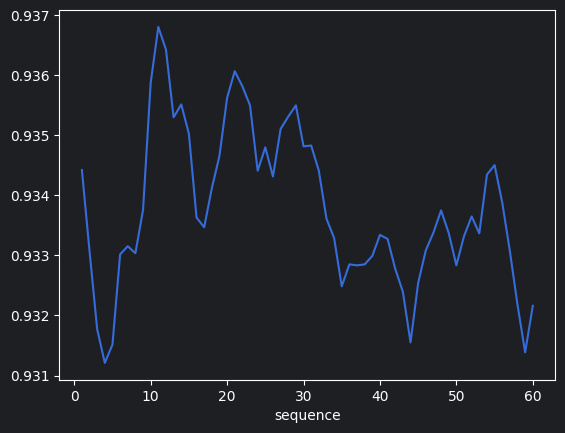

In [87]:
entropy_matrix_down.mean(axis = 1).plot(legend = False)

<Axes: xlabel='sequence'>

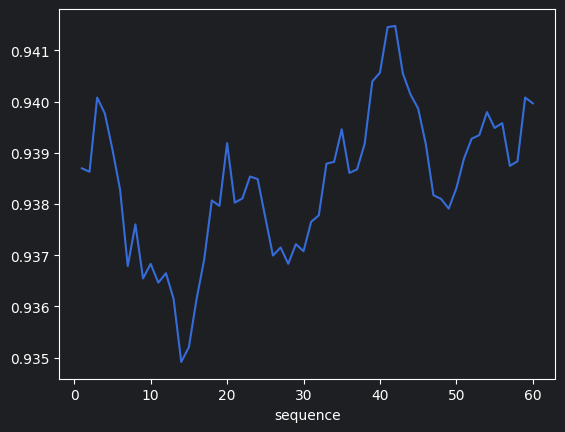

In [88]:
entropy_matrix_up.mean(axis = 1).plot(legend=False)

In [97]:


naaim = behavior.get_series(
    symbols = ['NAAIMAVG','NAAIMSTD','NAAIMESKEW'],
    index_set = 'release_date'
)

<Axes: >

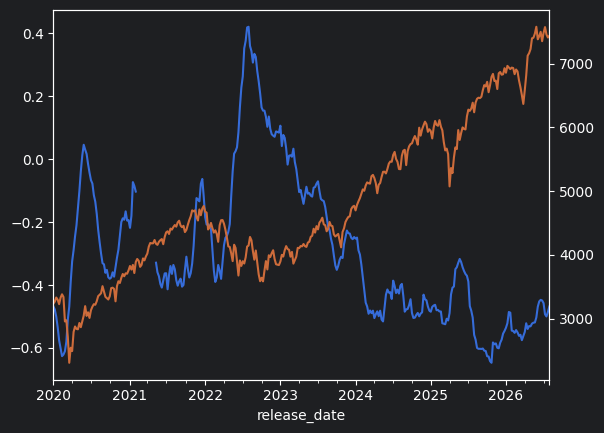

In [105]:
naaim['NAAIMESKEW'].rolling(13).mean().loc['2020':].plot()
selected_market_data['close'].resample('W-FRI').last().loc['2020':].plot(secondary_y = True)

<Axes: >

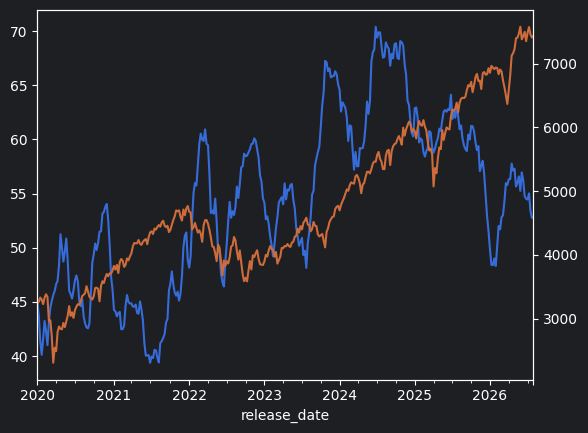

In [106]:
naaim['NAAIMSTD'].rolling(13).mean().loc['2020':].plot()
selected_market_data['close'].resample('W-FRI').last().loc['2020':].plot(secondary_y = True)